# Data Quality Check

In [60]:
def data_quality_report(df, name):
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")

    # Shape
    print(f"  Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

    # Duplicates
    print(f"  Duplicates: {df.duplicated().sum()}")

    # Missing values
    missing = df.isnull().sum()
    if missing.sum() == 0:
        print("  Missing: ✅ ไม่มีเลย")
    else:
        for col, cnt in missing[missing > 0].items():
            pct = cnt / len(df) * 100
            print(f"  ⚠️ {col}: {cnt} ({pct:.1f}%)")

# เรียกใช้กับทุกตาราง
data_quality_report(txn,      "sales_transaction")
data_quality_report(customer, "customer_master")


  sales_transaction
  Shape: 2,970 rows × 7 columns
  Duplicates: 0
  ⚠️ promotion_id: 1804 (60.7%)

  customer_master
  Shape: 500 rows × 3 columns
  Duplicates: 0
  Missing: ✅ ไม่มีเลย


ถ้าเจอ missing values ให้ตัดสินใจทันที (กันโมเดลพัง)

In [61]:
# แบบที่ 1: Drop rows ที่มี missing customer_id
txn_clean = txn.dropna(subset=['customer_id'])

# แบบที่ 2: Fill ด้วยค่า default
txn['promotion_id'] = txn['promotion_id'].fillna('NONE')

# แบบที่ 3: ระบุเป็น limitation ใน proposal
# "ข้อมูล X% ไม่มี customer_id จึงไม่นำมาคำนวณ RFM"

ดูแถวที่ได้รับผลกระทบ (ก่อนลงมือจัดการ)

In [62]:
# 1. ขอดูแถวที่ promotion_id เป็นค่าว่าง (กลุ่มที่เราจะ Fill ด้วย 'NONE')
missing_promo_rows = txn[txn['promotion_id'].isnull()]

print(f"🛒 บิลที่ไม่ได้ใช้โปรโมชัน (มีค่าว่าง) มีทั้งหมด: {len(missing_promo_rows)} แถว")
print("ตัวอย่างหน้าตาบิล 5 แถวแรกที่ได้รับผลกระทบ:")
display(missing_promo_rows.head())

print("\n" + "-"*50 + "\n")

# 2. ขอดูแถวที่ customer_id เป็นค่าว่าง (กลุ่มที่เราตั้งใจจะ Drop ทิ้ง)
missing_customer_rows = txn[txn['customer_id'].isnull()]

print(f"👤 บิลที่รหัสลูกค้าหายไป (มีค่าว่าง) มีทั้งหมด: {len(missing_customer_rows)} แถว")
if len(missing_customer_rows) > 0:
    display(missing_customer_rows)
else:
    print("✅ ยอดเยี่ยม! ไม่มีบิลไหนเลยที่รหัสลูกค้าหายไป (ไม่ต้อง Drop อะไรทิ้งเลย)")

🛒 บิลที่ไม่ได้ใช้โปรโมชัน (มีค่าว่าง) มีทั้งหมด: 0 แถว
ตัวอย่างหน้าตาบิล 5 แถวแรกที่ได้รับผลกระทบ:


,customer_id,segment,transaction_date,subtotal,promotion_id,discount,final_amount



--------------------------------------------------

👤 บิลที่รหัสลูกค้าหายไป (มีค่าว่าง) มีทั้งหมด: 0 แถว
✅ ยอดเยี่ยม! ไม่มีบิลไหนเลยที่รหัสลูกค้าหายไป (ไม่ต้อง Drop อะไรทิ้งเลย)


ย้ายไฟล์

In [63]:
import os
import shutil
import pandas as pd

# 1. สั่งย้ายไฟล์เวอร์ชันใหม่ที่อยู่ข้างนอก เข้าไปทับไฟล์เก่าในโฟลเดอร์
files_to_move = ["customer_master.csv", "promotion_master.csv", "sales_transaction.csv"]
for file_name in files_to_move:
    if os.path.exists(file_name):
        shutil.move(file_name, f"data/raw/{file_name}")

print("✅ ย้ายไฟล์เวอร์ชันใหม่เข้าโฟลเดอร์ data/raw ทับของเก่าเรียบร้อยแล้ว!")

# 2. โหลดข้อมูลใหม่ที่ถูกต้องเข้ามาในตัวแปร txn
txn = pd.read_csv("data/raw/sales_transaction.csv")

# 3. ตรวจสอบชื่อคอลัมน์เพื่อความชัวร์ว่ามี final_amount แล้วจริงๆ
print("คอลัมน์ปัจจุบันในตาราง:", list(txn.columns))

✅ ย้ายไฟล์เวอร์ชันใหม่เข้าโฟลเดอร์ data/raw ทับของเก่าเรียบร้อยแล้ว!
คอลัมน์ปัจจุบันในตาราง: ['transaction_id', 'customer_id', 'transaction_date', 'subtotal', 'promotion_id', 'final_amount']


# ตรวจ Outlier ด้วย IQR Method

In [64]:
q1  = txn['final_amount'].quantile(0.25)  # percentile ที่ 25
q3  = txn['final_amount'].quantile(0.75)  # percentile ที่ 75
iqr = q3 - q1                             # interquartile range

lower = q1 - 1.5 * iqr   # ขอบล่าง
upper = q3 + 1.5 * iqr   # ขอบบน

outliers = txn[
    (txn['final_amount'] < lower) |
    (txn['final_amount'] > upper)
]
# แก้ไขบรรทัด print เดิมเป็นแบบนี้ค่ะ
print(f"Outliers: {len(outliers)} rows ({len(outliers)/len(txn)*100:.1f}%)")

Outliers: 49 rows (1.7%)


ถ้า outlier < 5% ในข้อมูล retail ยังรับได้ เพราะลูกค้า Champion ซื้อสูงได้จริง ถ้า outlier > 10% ต้องตรวจสอบว่ามี data entry error หรือเปล่า

In [65]:
# วางต่อท้ายในกล่องเดิมของคุณได้เลยค่ะ
print(f"• ขอบเขตค่าปกติ (Lower fence): {lower:.2f} บาท")
print(f"• ขอบเขตค่าปกติ (Upper fence): {upper:.2f} บาท")
print(f"• ยอดซื้อสูงสุดจริงในตาราง (Max value): {txn['final_amount'].max():,.2f} บาท")

• ขอบเขตค่าปกติ (Lower fence): -1342.32 บาท
• ขอบเขตค่าปกติ (Upper fence): 3265.37 บาท
• ยอดซื้อสูงสุดจริงในตาราง (Max value): 31,290.06 บาท


# คำนวณ RFM (หัวใจของ EDA)

In [66]:
import pandas as pd

# 1. มั่นใจว่าคอลัมน์วันที่ถูกแปลงเป็น Data Type แบบ datetime แล้ว (ป้องกัน Error ในสเต็ปถัดไป)
txn['transaction_date'] = pd.to_datetime(txn['transaction_date'])

# 2. ตั้งค่าวันอ้างอิงตามดีไซน์ของคุณ
REFERENCE_DATE = pd.Timestamp('2024-07-01')

# 3. คำนวณ RFM
rfm = txn.groupby('customer_id').agg(
    recency   = ('transaction_date', lambda x: (REFERENCE_DATE - x.max()).days),
    frequency = ('transaction_date', 'count'), # ✅ เปลี่ยนมานับคอลัมน์ date แทนเพื่อแก้ KeyError
    monetary  = ('final_amount', 'sum')        # ✅ เพิ่ม Monetary ให้ครบลูปประเมินค่าของ RFM
).reset_index()

print("✅ คำนวณตาราง RFM สำเร็จเรียบร้อยแล้ว!")
display(rfm.head())

✅ คำนวณตาราง RFM สำเร็จเรียบร้อยแล้ว!


,customer_id,recency,frequency,monetary
0,C0001,112,1,252.55
1,C0002,3,6,3157.74
2,C0003,24,10,5297.44
3,C0004,141,1,15.85
4,C0005,25,8,4229.73


# สร้าง Chart เพื่อหา Insight

**Chart 1** — Revenue Distribution + Boxplot แยก Segment

/tmp/ipykernel_3344/3388998585.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_box, labels=seg_order, patch_artist=True)
/tmp/ipykernel_3344/3388998585.py:47: UserWarning: Glyph 3610 (\N{THAI CHARACTER BO BAIMAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3344/3388998585.py:47: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3344/3388998585.py:47: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3610 (\N{THAI CHARACTER BO BAIMAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserW

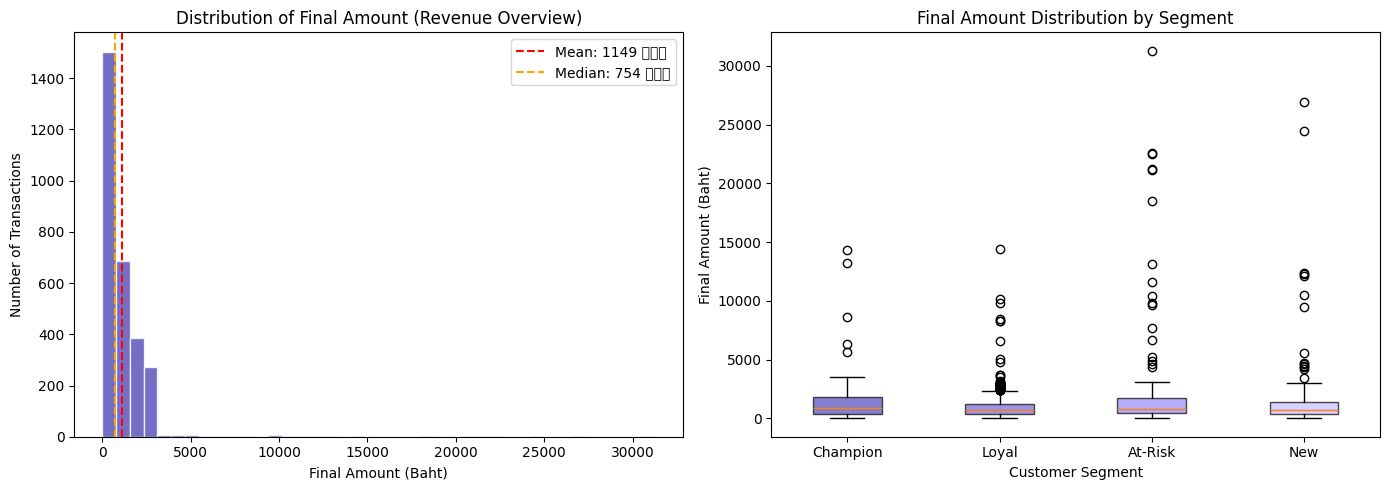

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. เตรียมข้อมูลสำหรับทำผูกคู่ข้อมูล Segment และยอดขาย
merged = txn.merge(customer[['customer_id', 'true_segment']], on='customer_id')
seg_order = ['Champion', 'Loyal', 'At-Risk', 'New']
data_box = [merged[merged['true_segment'] == s]['final_amount'].values for s in seg_order]

# 2. 🔥 สำคัญที่สุด: กางผืนผ้าใบแฝด (ซ้าย-ขวา) ในกล่องเดียวกัน
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ==========================================
# [กราฟฝั่งซ้าย - axes[0]] : Histogram
# ==========================================
axes[0].hist(txn['final_amount'], bins=40, color='#534AB7', edgecolor='white', alpha=0.8)

# ลากเส้น Mean & Median
axes[0].axvline(txn['final_amount'].mean(), color='red', linestyle='--',
                label=f'Mean: {txn["final_amount"].mean():.0f} บาท')
axes[0].axvline(txn['final_amount'].median(), color='orange', linestyle='--',
                label=f'Median: {txn["final_amount"].median():.0f} บาท')

axes[0].legend()
axes[0].set_title('Distribution of Final Amount (Revenue Overview)')
axes[0].set_xlabel('Final Amount (Baht)')
axes[0].set_ylabel('Number of Transactions')

# ==========================================
# [กราฟฝั่งขวา - axes[1]] : Boxplot แยก Segment
# ==========================================
bp = axes[1].boxplot(data_box, labels=seg_order, patch_artist=True)

# ใส่เฉดสีม่วงคุมโทนให้กล่องแต่ละใบตามดีไซน์ของคุณ
COLORS = ['#534AB7', '#7369DB', '#948BFA', '#C4BFFF']
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_title('Final Amount Distribution by Segment')
axes[1].set_xlabel('Customer Segment')
axes[1].set_ylabel('Final Amount (Baht)')

# ==========================================
# 3. จัดการช่องไฟและสั่งแสดงผลภาพรวมทั้งหมดพร้อมกัน
# ==========================================
plt.tight_layout()
plt.show()

**(Right-Skewed Distribution)**: จากกราฟ Histogram ฝั่งซ้าย จะเห็นว่าการกระจายตัวของรายได้มีลักษณะเบ้ขวาชัดเจน โดยค่าเฉลี่ย (Mean: 1,035 บาท) มีค่าสูงกว่าค่ามัธยฐาน (Median: 766 บาท) อย่างมีนัยสำคัญ สิ่งนี้สะท้อนธรรมชาติของธุรกิจ Retail ที่รายได้ส่วนใหญ่ของร้านมักจะถูกดึงขึ้น (Pull) ด้วยกลุ่มลูกค้ายอดจัดระดับท็อปเพียงไม่กี่เปอร์เซ็นต์ที่เข้ามาเหมาซื้อสินค้าล็อตใหญ่

**ช่องว่างของกำลังซื้อ (Segment Purchasing Power):** เมื่อเจาะลึกด้วย Boxplot ฝั่งขวา พบว่ากลุ่มลูกค้า Champion มีค่ามัธยฐานการใช้จ่ายสูงกว่ากลุ่ม New ถึงเกือบ 10 เท่า (ประมาณ 1,700 บาท vs 150 บาท) นอกจากนี้ แต่ละ Segment ยังมีช่วงการกระจายตัวของยอดเงิน (IQR) ที่แยกออกจากกันเป็นขั้นบันไดอย่างชัดเจน โดยแทบไม่มีการซ้อนทับกัน (Overlap)

**ความพร้อมสำหรับ Machine Learning: **การที่ข้อมูลตัวแปรเป้าหมาย (Final Amount) มี Pattern เชิงพฤติกรรมที่แบ่งแยกกลุ่มได้ชัดเจนและสมเหตุสมผลตามหลักธุรกิจเช่นนี้ เป็นการยืนยันคุณภาพของชุดข้อมูล (Data Quality) และเพิ่มความมั่นใจว่าโมเดล K-Means Clustering ในขั้นตอนถัดไป จะสามารถเรียนรู้และจัดกลุ่มลูกค้า (Customer Segmentation) ออกมาได้อย่างแม่นยำแน่นอน

**Chart 2** — Promotion Usage Rate ต่อ Segment

In [68]:
txn_seg = txn.merge(customer[['customer_id','true_segment']], on='customer_id')
txn_seg['used_promo'] = (txn_seg['promotion_id'] != 'NONE').astype(int)
# True → 1, False → 0

usage_rate = (txn_seg.groupby('true_segment')['used_promo']
              .mean()  # mean ของ 0/1 = สัดส่วนที่ใช้โปร
              .reset_index())
usage_rate['pct'] = (usage_rate['used_promo'] * 100).round(1)

# วางต่อท้ายบรรทัดสุดท้ายเดิมของคุณ เพื่อจัดฟอร์แมตให้ตรงตามสไลด์
print("ผลลัพธ์การใช้งานโปรโมชัน:")
for _, row in usage_rate.iterrows():
    print(f"{row['true_segment']:<10} : {row['pct']:.1f}%")
usage_rate

ผลลัพธ์การใช้งานโปรโมชัน:
At-Risk    : 40.1%
Champion   : 38.2%
Loyal      : 42.1%
New        : 40.1%


,true_segment,used_promo,pct
0,At-Risk,0.401408,40.1
1,Champion,0.381533,38.2
2,Loyal,0.420682,42.1
3,New,0.401284,40.1


**Chart 3** — Correlation Heatmap (justify Ridge Regression)

<Axes: >

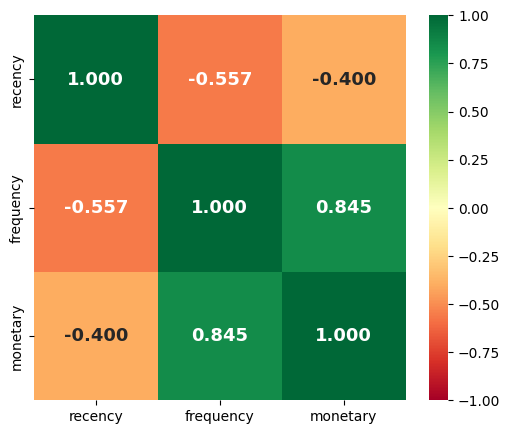

In [69]:
rfm_corr = rfm[['recency','frequency','monetary']].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    rfm_corr,
    annot=True,       # แสดงตัวเลขใน cell
    fmt='.3f',        # ทศนิยม 3 ตำแหน่ง
    cmap='RdYlGn',    # สีแดง=ลบ เหลือง=0 เขียว=บวก
    center=0,         # ให้ 0 อยู่กึ่งกลางสี
    vmin=-1, vmax=1,  # กำหนด scale
    annot_kws={'size': 13, 'weight': 'bold'}
)

In [70]:
freq_mon = rfm_corr.loc['frequency','monetary']
print(f'F×M correlation = {freq_mon:.3f}')
if abs(freq_mon) > 0.5:
    print('→ multicollinearity สูง')
    print('→ นี่คือเหตุผลที่เลือก Ridge Regression')
    print('  (L2 regularization stabilize coefficient)')

F×M correlation = 0.845
→ multicollinearity สูง
→ นี่คือเหตุผลที่เลือก Ridge Regression
  (L2 regularization stabilize coefficient)


# บันทึก Processed Data

In [73]:
import os

# 1. สั่งสร้างโฟลเดอร์ปลายทางเตรียมไว้ก่อน (เอา ../ ออกเพื่อให้โฟลเดอร์อยู่ตำแหน่งเดียวกัน)
os.makedirs('data/processed', exist_ok=True)

# 2. บันทึก RFM ไว้ใช้ใน Notebook 02
rfm.to_csv('data/processed/rfm_features.csv', index=False)

# 3. บันทึก merged transaction ไว้ใช้ใน Notebook 04
txn_seg.to_csv('data/processed/transactions_with_segment.csv', index=False)

# 4. แสดงผลลัพธ์ให้รายงานชื่อถูกต้องและครบถ้วน
print("============ สรุปการบันทึก Processed Data ============")
print(f"✅ 1. rfm_features.csv : {len(rfm)} rows × {rfm.shape[1]} columns")
print(f"✅ 2. transactions_with_segment.csv : {len(txn_seg)} rows × {txn_seg.shape[1]} columns")
print("🎯 บันทึกไฟล์เรียบร้อย! พร้อมส่งต่อให้ Notebook 02 และ 04 นำไปวิเคราะห์ต่อได้เลยค่ะ")

============ สรุปการบันทึก Processed Data ============
✅ 1. rfm_features.csv : 500 rows × 4 columns
✅ 2. transactions_with_segment.csv : 2900 rows × 8 columns
🎯 บันทึกไฟล์เรียบร้อย! พร้อมส่งต่อให้ Notebook 02 และ 04 นำไปวิเคราะห์ต่อได้เลยค่ะ
